
<h1><center>  ECNM10115 Programming and Numerical Methods for Economics </center></h1>
<h1><center>  Lab 2 </center></h1>

#### File from Learn - Course Material - Week 3
* functions.py
* UNPS_1112_PS2.xls

#### Import Libraries, Functions and Display Settings

In [99]:

import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
import os
# import seaborn as sns

os.chdir('C:/Users/jzurita/OneDrive - University of Edinburgh/Courses/Programming Numerical Methods/Week 3/')

from functions import  gini

# import warnings
# warnings.filterwarnings('ignore')  #sns warning disactivated

#display options: To print entire tables
# pd.options.display.float_format = '{:,.2f}'.format
# pd.set_option('display.max_columns', None)  # or 1000
# pd.set_option('display.max_rows', None)  # or 1000
# pd.set_option('display.max_colwidth', None)  # or 199

# plots display default options
# sns.set_palette("Set2")   # set of colors in seaborn
# import matplotlib as mpl
# fm = mpl.font_manager

# Import Data

In [97]:
data = pd.read_excel('UNPS_1112_PS2.xls')

In [65]:
data

,hhid,wave,year,region,district,county,urban,year_surv,month_surv,head_gender,...,income,wage_labor,business_inc,other_inc,agriculture_inc,livestock_inc,wealth,asset_value,wealth_agrls,land_value_hat
0,1013000204,2011-2012,2012,1,KALANGALA,KYAMUSWA,0,2012,3,1.0,...,717.277761,NaN,717.277761,0.000000,NaN,NaN,102.530580,102.530580,NaN,NaN
1,1013000206,2011-2012,2012,1,KAMPALA,RUBAGA DIVISION,0,2012,9,1.0,...,1839.529498,949.476802,890.052696,0.000000,NaN,NaN,821.989843,821.989843,NaN,NaN
2,1013000210,2011-2012,2012,1,KALANGALA,KYAMUSWA,0,2012,2,1.0,...,91.623072,NaN,NaN,0.000000,NaN,91.623072,1202.661890,268.324710,934.337180,NaN
3,1013000212,2011-2012,2012,4,KYEGEGWA,KYAKA,0,2012,3,1.0,...,2617.802047,1989.529555,628.272491,0.000000,NaN,NaN,494.764587,494.764587,NaN,NaN
4,101300021302,2011-2012,2012,1,MPIGI,MAWOKOTA,0,2012,4,2.0,...,811.518634,NaN,157.068123,654.450512,NaN,NaN,54.537543,54.537543,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2608,4193003504,2011-2012,2012,4,KIRUHURA,NYABUSHOZI,0,2012,2,2.0,...,1046.796900,NaN,NaN,0.000000,1037.634593,9.162307,11837.852383,256.108300,119.109993,11462.634090
2609,4193003506,2011-2012,2012,4,KIRUHURA,NYABUSHOZI,0,2012,2,1.0,...,10505.763174,NaN,8376.966549,130.890102,668.412123,1329.494399,6291.311323,405.759317,4794.940749,1090.611257
2610,4193003507,2011-2012,2012,4,KIRUHURA,NYABUSHOZI,0,2012,2,2.0,...,1216.754391,NaN,NaN,0.000000,848.167863,368.586528,1888.801009,241.274089,271.596962,1375.929958
2611,4193003508,2011-2012,2012,4,KIRUHURA,NYABUSHOZI,0,2012,8,1.0,...,814.485477,NaN,NaN,0.000000,814.485477,NaN,4142.348323,842.059658,10.471208,3289.817457


#### Note

Make sure you have installed **_xlrd_** package. Otherwise, you might have some difficulties to read the data file.

To install this package run: 

**conda install anaconda::xlrd**

<hhtml>https://anaconda.org/anaconda/xlrd

In [101]:
!pip install xlrd 

## Exercise 1


a). Are there duplicate households in the data? i.e. repeated household id?. How many observations?

In [65]:
data[data.duplicated(keep=False)]  
print('1a =======)')
print('There are no duplicate households')

# total number of observations
print('The total number of obsertations is N=', sum(data['hhid'].notna()))


1a =======)
There are no duplicate households
The total number of obsertations is N= 2613


b) Present some basic summary statistics for some main variables. Anything we should be careful? like missing a lot of observations?


In [16]:
print('1b =======)')
print(data[['head_gender','head_age','familysize','consumption','income','wealth']].describe())

1b =======)
       head_gender     head_age   familysize  consumption        income  \
count  2597.000000  2597.000000  2597.000000  2613.000000   2613.000000   
mean      1.314209    46.068156     7.480554  1803.792687   1860.075795   
std       0.464289    15.068960     3.712526  1308.742941   2607.517603   
min       1.000000    14.000000     1.000000   250.305506     27.486921   
25%       1.000000    34.000000     5.000000   918.324958    471.204368   
50%       1.000000    44.000000     7.000000  1426.614855   1061.194208   
75%       2.000000    56.000000     9.000000  2296.859516   2234.800590   
max       2.000000   100.000000    33.000000  8369.898484  52137.736864   

             wealth  
count   2613.000000  
mean    4912.698146  
std     8359.886497  
min        0.000000  
25%      720.019916  
50%     2108.598380  
75%     5221.939857  
max    76396.339917  


## Exercise 2

#### a) Create the variables 'log_c' 'log_inc', 'log_w' that are the log of consumption, income, and wealth.

In [67]:
data[['consumption','income','wealth']].describe()  # 2613 observations. No observations below 0, but some equal to zero.

,consumption,income,wealth
count,2613.000000,2613.000000,2613.000000
mean,1803.792687,1860.075795,4912.698146
std,1308.742941,2607.517603,8359.886497
min,250.305506,27.486921,0.000000
25%,918.324958,471.204368,720.019916
50%,1426.614855,1061.194208,2108.598380
75%,2296.859516,2234.800590,5221.939857
max,8369.898484,52137.736864,76396.339917


In [75]:
# Create the logs
data[['log_c','log_inc','log_w']] = np.log(data[['consumption','income','wealth']])
data[['log_c','log_inc','log_w']] .describe()

,log_c,log_inc,log_w
count,2613.000000,2613.000000,2613.000000
mean,7.273602,6.912703,-inf
std,0.670492,1.157038,NaN
min,5.522682,3.313710,-inf
25%,6.822551,6.155292,6.579279
50%,7.263060,6.967150,7.653779
75%,7.739298,7.711907,8.560624
max,9.032397,10.861644,11.243690


In [81]:
##
data[['log_c','log_inc','log_w']] = data[['log_c','log_inc','log_w']].replace([-np.infty], np.nan)
### The log-variance measure of inequality is not the best when there might be a lot of zeros in the data.

data[['log_c','log_inc','log_w']].describe()

,log_c,log_inc,log_w
count,2613.000000,2613.000000,2597.000000
mean,7.273602,6.912703,7.475775
std,0.670492,1.157038,1.636211
min,5.522682,3.313710,0.269188
25%,6.822551,6.155292,6.600676
50%,7.263060,6.967150,7.664869
75%,7.739298,7.711907,8.565685
max,9.032397,10.861644,11.243690


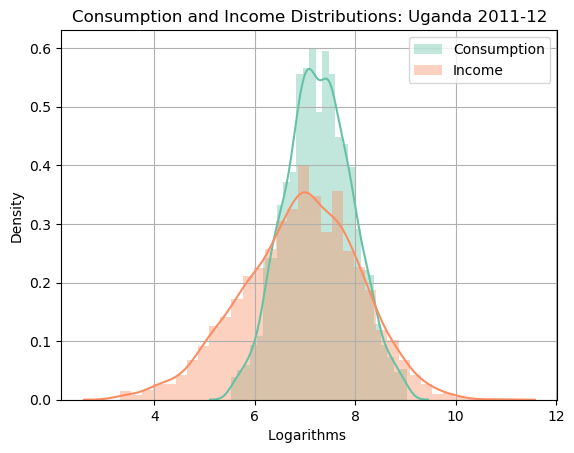

In [91]:
# plot in the same graph the log_c and the log_inc. 
fig, ax = plt.subplots()
sns.distplot(data[['log_c']], label='Consumption')
sns.distplot(data[['log_inc']], label='Income')
plt.title('Consumption and Income Distributions: Uganda 2011-12')
plt.xlabel('Logarithms ')
plt.ylabel('Density')
ax.legend()
ax.grid()
plt.show()

#### e) Inequality compute the Gini of Consumption, Income and Wealth.

In [75]:
gini_ciw = data[['consumption','income','wealth']].apply(gini)
gini_ciw = pd.DataFrame(gini_ciw,columns=['Gini'])
print('    ')
print('2e =======')
print('Inequality in Uganda: Gini coefficients')
print(gini_ciw)

    
2e =======
Inequality in Uganda: Gini coefficients
                 Gini
consumption  0.365717
income       0.555572
wealth       0.656828


#### f)  Compute the share of wealth of the bottom 50%. 

In [50]:

shares = [0.5]
bottom = [0]
bottom.extend(shares) #[0 0.5]
    
var_array = np.sort(np.array(data['wealth'].dropna()))
var_total = sum(var_array) # Total Sum of Data Wealth
    
n= len(var_array)
percentiles = n*np.array(bottom)  # [0.0  0.5]
percentiles = percentiles.tolist()
percentiles = [int(x) for x in percentiles] ### Round to interger
    
mg_bottom= []
for i in range(1,len(percentiles)):  # len(percentiles)=2
    print(i)
    a = sum(var_array[percentiles[0]:percentiles[i]])/var_total
    mg_bottom.append(a)
    
              
mg_bottom

1


[0.08210562223168812]

In [52]:
mg_bottom

[0.08210562223168812]

In [46]:
percentiles

[0, 1306]

In [25]:
# f.  Compute the share of wealth of the bottom 50%.  that the top 10, 5, 1% in wealth hold. 
def bottom_shares(variable, dataset, shares = [0.5]):
    bottom = [0]
    bottom.extend(shares)
    
    var_array = np.sort(np.array(dataset[variable].dropna()))
    var_total = sum(var_array)
    
    n= len(var_array)
    percentiles = n*np.array(bottom)
    percentiles = percentiles.tolist()
    percentiles = [int(x) for x in percentiles] 
    
    mg_bottom= []
    for i in range(1,len(percentiles)):
        print(i)
        a = sum(var_array[percentiles[0]:percentiles[i]])/var_total
        mg_bottom.append(a)
              
    return mg_bottom

w_bottom = bottom_shares('wealth',dataset=data,shares=[0.25])
print('    ')
print('2f =======')
print('The Bottom 50% hold only 8% of the total wealth in Uganda')


def top_shares(variable, dataset, shares =[ 0.90, 0.95, 0.99]):

    shares.append(1)
    var_array = np.sort(np.array(dataset[variable].dropna()))
    var_total = sum(var_array)
    n= len(var_array)
    percentiles = n*np.array(shares) # multiple the vector by weights or shares. 
    percentiles = percentiles.tolist()
    percentiles = [int(x) for x in percentiles]
    
    mg_top = []
    for i in range(0,len(percentiles)-1):
        a = sum(var_array[percentiles[i]:percentiles[-1]])/var_total
        mg_top.append(a)               
    return  mg_top

w_top = top_shares('wealth',dataset=data,shares=[0.90, 0.95, 0.99])
print('the top 10%, 5% and 1% share 50%, 35%, and 11% of the wealth in the economy.')

1
    
2f =======
The Bottom 50% hold only 8% of the total wealth in Uganda
the top 10%, 5% and 1% share 50%, 35%, and 11% of the wealth in the economy.


(2613,)

In [90]:
percentiles

[0, 1306]

In [96]:
shares =[ 0.90, 0.95, 0.99]
shares.append(1)
shares

[0.9, 0.95, 0.99, 1]